In [2]:
import pandas as pd
import numpy as np

In [5]:
df=pd.read_csv("/content/dataset.csv", engine='python', on_bad_lines='skip')
df

,Role,Resume,Decision,Reason_for_decision,Job_Description
0,E-commerce Specialist,Here's a professional resume for Jason Jones:\...,reject,Lacked leadership skills for a senior position.,Be part of a passionate team at the forefront ...
1,Game Developer,Here's a professional resume for Ann Marshall:...,select,Strong technical skills in AI and ML.,Help us build the next-generation products as ...
2,Human Resources Specialist,Here's a professional resume for Patrick Mccla...,reject,Insufficient system design expertise for senio...,We need a Human Resources Specialist to enhanc...
3,E-commerce Specialist,Here's a professional resume for Patricia Gray...,select,Impressive leadership and communication abilit...,Be part of a passionate team at the forefront ...
4,E-commerce Specialist,Here's a professional resume for Amanda Gross:...,reject,Lacked leadership skills for a senior position.,We are looking for an experienced E-commerce S...
...,...,...,...,...,...
1401,Software Engineer,**Sophia**\n**Contact Information:**\n\n* Emai...,select,"Proven expertise in System architecture, Versi...",Seeking an experienced Software Engineer with ...
1402,Product Manager,**Zara**\n**Contact Information:**\n\n* Email:...,select,The candidate has a solid background in User e...,Join our team as a Product Manager and leverag...
1403,Data Engineer,**Emily**\n**Data Engineer**\n\n**Contact Info...,select,The candidate's 8 years of experience combined...,Seeking an experienced Data Engineer with 8 ye...
1404,Data Scientist,**Mason**\n**Data Scientist**\n\n**Contact Inf...,select,The candidate's 7 years of experience combined...,Seeking an experienced Data Scientist with 7 y...


In [6]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pickle


In [7]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1406 entries, 0 to 1405
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Role                 1406 non-null   object
 1   Resume               1406 non-null   object
 2   Decision             1406 non-null   object
 3   Reason_for_decision  1406 non-null   object
 4   Job_Description      1406 non-null   object
dtypes: object(5)
memory usage: 55.1+ KB
None
Role                   0
Resume                 0
Decision               0
Reason_for_decision    0
Job_Description        0
dtype: int64


In [8]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # remove numbers & symbols
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)


In [10]:
df['cleaned_resume'] = df['Resume'].apply(clean_text)
df['cleaned_resume']

,cleaned_resume
0,professional resume jason jones jason jones e ...
1,professional resume ann marshall ann marshall ...
2,professional resume patrick mcclain patrick mc...
3,professional resume patricia gray patricia gra...
4,professional resume amanda gross amanda gross ...
...,...
1401,sophia contact information email sophia email ...
1402,zara contact information email zara email com ...
1403,emily data engineer contact information phone ...
1404,mason data scientist contact information email...


In [11]:
print(df[['Resume', 'cleaned_resume']].head())

                                              Resume  \
0  Here's a professional resume for Jason Jones:\...   
1  Here's a professional resume for Ann Marshall:...   
2  Here's a professional resume for Patrick Mccla...   
3  Here's a professional resume for Patricia Gray...   
4  Here's a professional resume for Amanda Gross:...   

                                      cleaned_resume  
0  professional resume jason jones jason jones e ...  
1  professional resume ann marshall ann marshall ...  
2  professional resume patrick mcclain patrick mc...  
3  professional resume patricia gray patricia gra...  
4  professional resume amanda gross amanda gross ...  


In [12]:
X = df['cleaned_resume']   # Input
y = df['Decision']         # Output (select / reject)

In [13]:
print(y.head())

0    reject
1    select
2    reject
3    select
4    reject
Name: Decision, dtype: object


In [14]:
print(df[['cleaned_resume', 'Decision']].head())


                                      cleaned_resume Decision
0  professional resume jason jones jason jones e ...   reject
1  professional resume ann marshall ann marshall ...   select
2  professional resume patrick mcclain patrick mc...   reject
3  professional resume patricia gray patricia gra...   select
4  professional resume amanda gross amanda gross ...   reject


In [15]:
vectorizer = TfidfVectorizer()

X_vectorized = vectorizer.fit_transform(X)
print(X_vectorized.shape)


(1406, 7125)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)


(1124, 7125)
(282, 7125)


In [17]:
model = LogisticRegression()
model.fit(X_train, y_train)

print("Model Training Completed ✅")



Model Training Completed ✅


In [18]:
# Generate predictions on the test set
y_pred = model.predict(X_test)
print("Predictions (y_pred) on test set generated successfully.")

Predictions (y_pred) on test set generated successfully.


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
# For binary classification with 'select' and 'reject', we need to specify pos_label
# Assuming 'select' is the positive class
precision = precision_score(y_test, y_pred, pos_label='select')

# Sensitivity (Recall)
sensitivity = recall_score(y_test, y_pred, pos_label='select')

# F1-score
f1 = f1_score(y_test, y_pred, pos_label='select')

# Specificity (calculated from confusion matrix)
cm = confusion_matrix(y_test, y_pred, labels=['reject', 'select'])
TN, FP, FN, TP = cm.ravel()
specificity = TN / (TN + FP)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (for 'select' class): {precision:.4f}")
print(f"Sensitivity (Recall for 'select' class): {sensitivity:.4f}")
print(f"Specificity (for 'reject' class): {specificity:.4f}")
print(f"F1-Score (for 'select' class): {f1:.4f}")

Accuracy: 0.5248
Precision (for 'select' class): 0.5096
Sensitivity (Recall for 'select' class): 0.3897
Specificity (for 'reject' class): 0.6507
F1-Score (for 'select' class): 0.4417


In [20]:
new_resumes = [
    "Experienced Python Developer with Django and Flask knowledge",
    "Looking for job opportunity",
    "Data Scientist skilled in Machine Learning and Deep Learning"
]

cleaned_resumes = [clean_text(resume) for resume in new_resumes]

vectorized_resumes = vectorizer.transform(cleaned_resumes)

predictions = model.predict(vectorized_resumes)

for resume, decision in zip(new_resumes, predictions):
    print("\nResume:", resume)
    print("Decision:", decision)



Resume: Experienced Python Developer with Django and Flask knowledge
Decision: reject

Resume: Looking for job opportunity
Decision: reject

Resume: Data Scientist skilled in Machine Learning and Deep Learning
Decision: reject


In [21]:
all_predictions = model.predict(X_vectorized)

df['Predicted_Decision'] = all_predictions

print(df[['Decision', 'Predicted_Decision']].head())


  Decision Predicted_Decision
0   reject             reject
1   select             select
2   reject             reject
3   select             select
4   reject             reject


In [22]:
df['Decision'].value_counts()

,count
Decision,
reject,734
select,672


In [23]:
pickle.dump(model, open("resume_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

print("Model Saved Successfully ✅")


Model Saved Successfully ✅


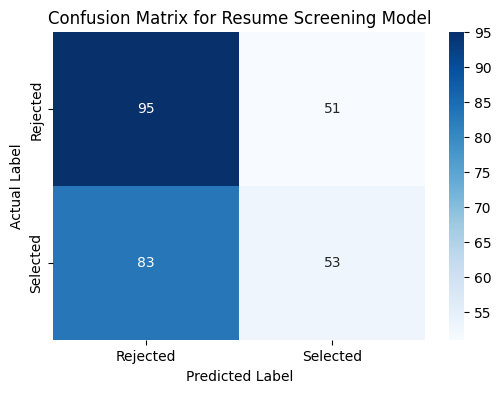

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Rejected', 'Selected'],
            yticklabels=['Rejected', 'Selected'])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix for Resume Screening Model")

plt.show()

In [25]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0] # Assuming binary classification, we take the coefficients for one class

# Create a DataFrame for easier analysis
feature_importance = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})

# Sort by coefficient to find most influential features for 'select' (positive) and 'reject' (negative)
feature_importance_sorted = feature_importance.sort_values(by='coefficient', ascending=False)

print("\nTop 10 features influencing 'select' decision (positive coefficients):")
print(feature_importance_sorted.head(10))

print("\nTop 10 features influencing 'reject' decision (negative coefficients):")
print(feature_importance_sorted.tail(10))


Top 10 features influencing 'select' decision (positive coefficients):
            feature  coefficient
2637         github     0.803045
4084      marketing     0.727009
1105    christopher     0.657885
4082         market     0.654526
5132          prize     0.650375
3364        jessica     0.643939
6886  visualization     0.634762
5896        section     0.620116
5844      scientist     0.602199
4969       pipeline     0.577666

Top 10 features influencing 'reject' decision (negative coefficients):
             feature  coefficient
1458            cost    -0.588631
6369           susan    -0.619657
5326          ranked    -0.623060
4336       migration    -0.628070
3313         jeffrey    -0.630943
3438         johnson    -0.638509
1787          dental    -0.659002
3078  infrastructure    -0.689849
6102           sonia    -0.821110
6507              th    -0.905535


In [26]:
role_decision_counts = df.groupby(['Role', 'Decision']).size().unstack(fill_value=0)
role_decision_percentages = role_decision_counts.apply(lambda x: x / x.sum() * 100, axis=1)

print("Counts of Decisions by Role:")
print(role_decision_counts.head())
print("\nPercentages of Decisions by Role:")
print(role_decision_percentages.head())

Counts of Decisions by Role:
Decision              reject  select
Role                                
AI Researcher             12      15
AR/VR Developer           19      18
Blockchain Developer      24      11
Business Analyst          20      15
Cloud Architect           16      13

Percentages of Decisions by Role:
Decision                 reject     select
Role                                      
AI Researcher         44.444444  55.555556
AR/VR Developer       51.351351  48.648649
Blockchain Developer  68.571429  31.428571
Business Analyst      57.142857  42.857143
Cloud Architect       55.172414  44.827586


<Figure size 1500x800 with 0 Axes>

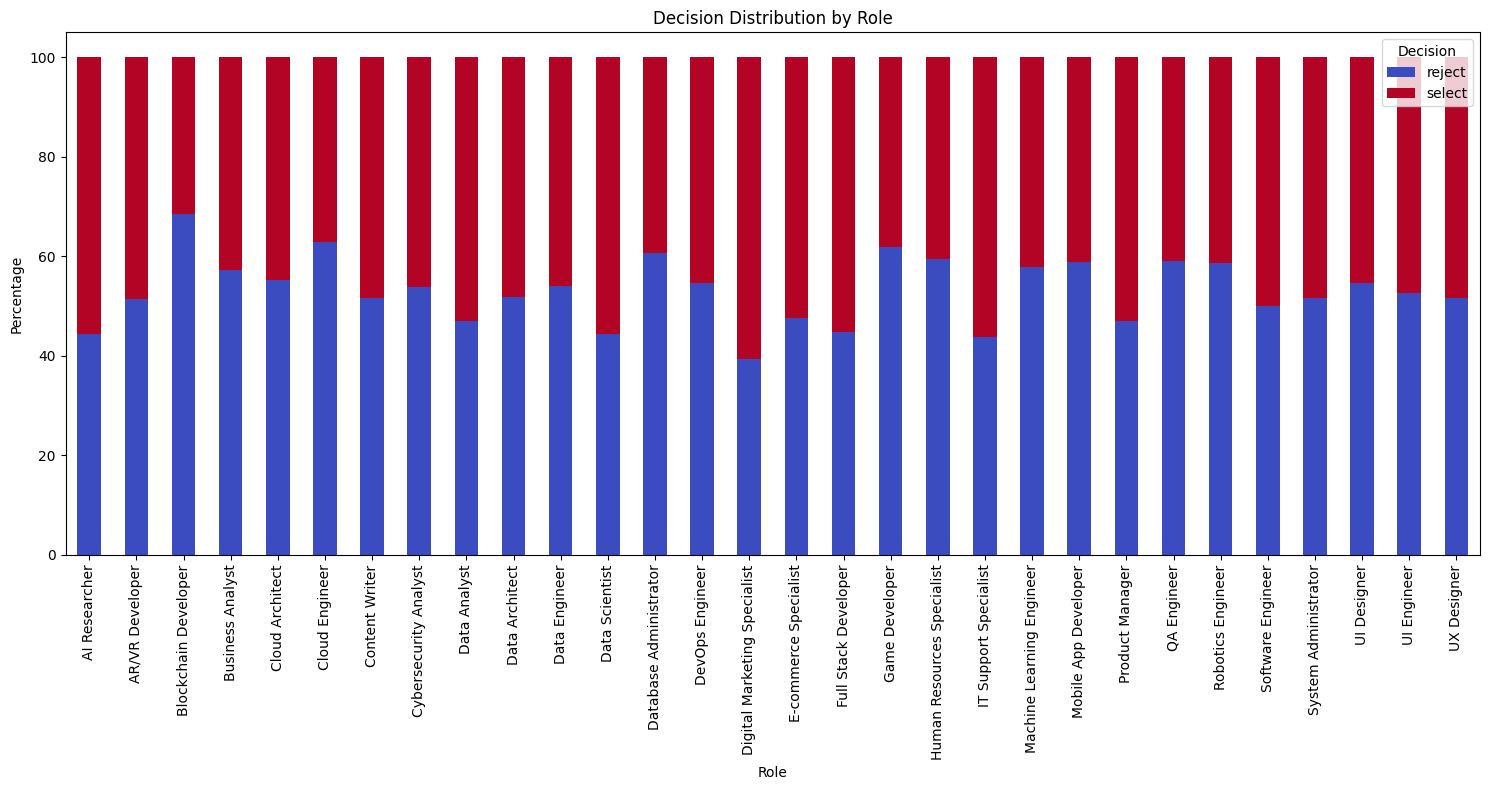

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the percentages
plt.figure(figsize=(15, 8))
role_decision_percentages.plot(kind='bar', stacked=True, cmap='coolwarm', figsize=(15, 8))
plt.title('Decision Distribution by Role')
plt.xlabel('Role')
plt.ylabel('Percentage')
plt.xticks(rotation=90)
plt.legend(title='Decision')
plt.tight_layout()
plt.show()

In [28]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
import numpy as np

print("Scikit-learn Perceptron libraries imported successfully.")

Scikit-learn Perceptron libraries imported successfully.


In [29]:
# Initialize the scikit-learn Perceptron model
# random_state for reproducibility
# early_stopping=True can help if data is not linearly separable
# max_iter is for number of passes over the training data
perceptron_sklearn = Perceptron(random_state=42, early_stopping=True, max_iter=1000, tol=1e-3)

# The Perceptron in scikit-learn expects target labels to be -1 and 1, or 0 and 1.
# Our 'select' and 'reject' can be mapped to 1 and 0 directly.
# X_vectorized and y are already defined from previous steps.

# Split data into training and testing sets for proper evaluation
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

# Train the Perceptron model
perceptron_sklearn.fit(X_train_p, y_train_p)

# Make predictions on the test set
y_pred_sklearn = perceptron_sklearn.predict(X_test_p)

# Evaluate the model
accuracy_sklearn = accuracy_score(y_test_p, y_pred_sklearn)
print(f"Scikit-learn Perceptron Model Evaluation:\nAccuracy: {accuracy_sklearn:.4f}")

# Print classification report for more details
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test_p, y_pred_sklearn))

Scikit-learn Perceptron Model Evaluation:
Accuracy: 0.5142

Classification Report:
              precision    recall  f1-score   support

      reject       0.53      0.54      0.54       146
      select       0.50      0.49      0.49       136

    accuracy                           0.51       282
   macro avg       0.51      0.51      0.51       282
weighted avg       0.51      0.51      0.51       282



In [30]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import make_classification

# Generate a synthetic dataset for binary classification
X_log, y_log = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, random_state=42)

# Split data into training and testing sets
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.3, random_state=42)

# Initialize and train the Logistic Regression model
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_log, y_train_log)

# Make predictions
y_pred_log = log_model.predict(X_test_log)

# Evaluate the model
print("Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_log, y_pred_log):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_log, y_pred_log))

Logistic Regression Model Evaluation:
Accuracy: 0.8333

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84        32
           1       0.80      0.86      0.83        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60



In [31]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Generate synthetic data for Simple Linear Regression
np.random.seed(42) # for reproducibility
X_slr = np.random.rand(100, 1) * 10  # Independent variable
y_slr = 2 * X_slr + 3 + np.random.randn(100, 1) * 2  # Dependent variable with some noise

# Split data into training and testing sets
X_train_slr, X_test_slr, y_train_slr, y_test_slr = train_test_split(X_slr, y_slr, test_size=0.3, random_state=42)

# Initialize and train the Simple Linear Regression model
slr_model = LinearRegression()
slr_model.fit(X_train_slr, y_train_slr)

# Make predictions
y_pred_slr = slr_model.predict(X_test_slr)

# Evaluate the model
mse_slr = mean_squared_error(y_test_slr, y_pred_slr)
rmse_slr = np.sqrt(mse_slr)
mae_slr = mean_absolute_error(y_test_slr, y_pred_slr)
r2_slr = r2_score(y_test_slr, y_pred_slr)

print("Simple Linear Regression Model Evaluation:")
print(f"MSE: {mse_slr:.4f}")
print(f"RMSE: {rmse_slr:.4f}")
print(f"MAE: {mae_slr:.4f}")
print(f"R-squared: {r2_slr:.4f}")

Simple Linear Regression Model Evaluation:
MSE: 2.5238
RMSE: 1.5886
MAE: 1.1947
R-squared: 0.9412


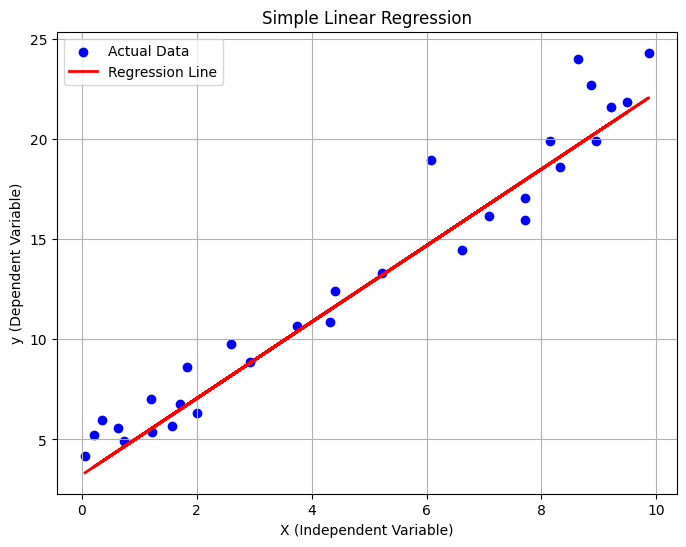

In [32]:
# Plotting the regression line
plt.figure(figsize=(8, 6))
plt.scatter(X_test_slr, y_test_slr, color='blue', label='Actual Data')
plt.plot(X_test_slr, y_pred_slr, color='red', linewidth=2, label='Regression Line')
plt.xlabel('X (Independent Variable)')
plt.ylabel('y (Dependent Variable)')
plt.title('Simple Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

In [33]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Generate synthetic data for Multiple Linear Regression
np.random.seed(42) # for reproducibility
X_mlr = np.random.rand(100, 3) * 10  # 100 samples, 3 independent variables
y_mlr = 2 * X_mlr[:, 0] + 1.5 * X_mlr[:, 1] - 3 * X_mlr[:, 2] + 5 + np.random.randn(100) * 5 # Dependent variable with some noise

# Split data into training and testing sets
X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(X_mlr, y_mlr, test_size=0.3, random_state=42)

# Initialize and train the Multiple Linear Regression model
mlr_model = LinearRegression()
mlr_model.fit(X_train_mlr, y_train_mlr)

# Make predictions
y_pred_mlr = mlr_model.predict(X_test_mlr)

# Evaluate the model
mse_mlr = mean_squared_error(y_test_mlr, y_pred_mlr);
rmse_mlr = np.sqrt(mse_mlr)
mae_mlr = mean_absolute_error(y_test_mlr, y_pred_mlr)
r2_mlr = r2_score(y_test_mlr, y_pred_mlr)

print("Multiple Linear Regression Model Evaluation:")
print(f"MSE: {mse_mlr:.4f}")
print(f"RMSE: {rmse_mlr:.4f}")
print(f"MAE: {mae_mlr:.4f}")
print(f"R-squared: {r2_mlr:.4f}")

Multiple Linear Regression Model Evaluation:
MSE: 37.7133
RMSE: 6.1411
MAE: 4.6604
R-squared: 0.7916


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

print("Libraries imported successfully.")

Libraries imported successfully.


In [35]:
# Generate a synthetic dataset for binary classification
X_svm, y_svm = datasets.make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, random_state=42)

# Split data into training and testing sets
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_svm, y_svm, test_size=0.3, random_state=42)

print("Synthetic dataset generated and split into training/testing sets.")

Synthetic dataset generated and split into training/testing sets.


In [36]:
# Initialize and train the SVM model
# Using a radial basis function (RBF) kernel, which is common for non-linear decision boundaries
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_svm, y_train_svm)

print("SVM model trained successfully.")

SVM model trained successfully.


SVM Model Evaluation:
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        14

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



/tmp/ipykernel_614/1074446798.py:16: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_svm[:, 0], X_test_svm[:, 1], c=y_test_svm, cmap=plt.cm.coolwarm, edgecolors='k', marker='x', s=100, linewidths=2, label='Test Data')


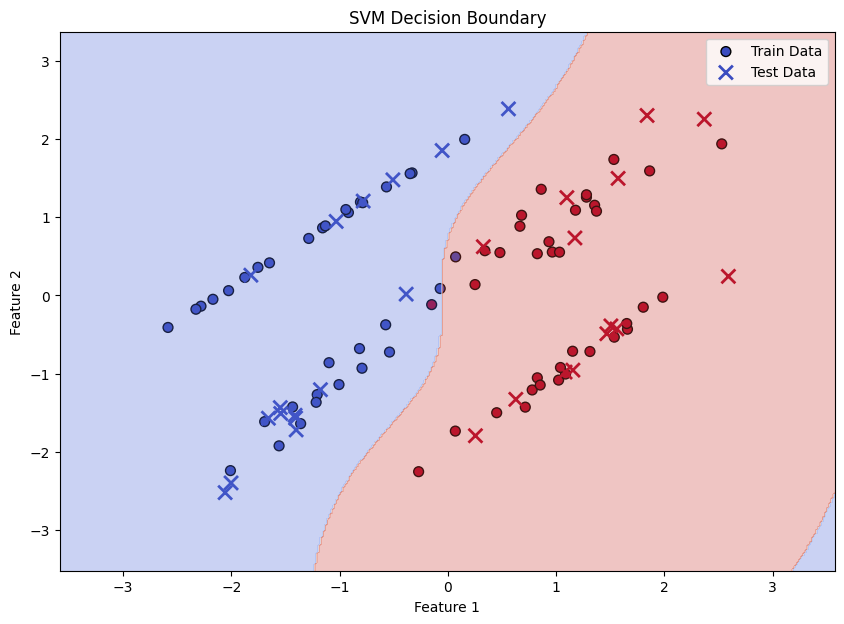

In [37]:
# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test_svm)

# Evaluate the model
accuracy_svm = accuracy_score(y_test_svm, y_pred_svm)
print(f"SVM Model Evaluation:\nAccuracy: {accuracy_svm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_svm, y_pred_svm))

# Visualize the decision boundary
plt.figure(figsize=(10, 7))

# Plot the training points
plt.scatter(X_train_svm[:, 0], X_train_svm[:, 1], c=y_train_svm, cmap=plt.cm.coolwarm, edgecolors='k', marker='o', s=50, label='Train Data')
# Plot the test points
plt.scatter(X_test_svm[:, 0], X_test_svm[:, 1], c=y_test_svm, cmap=plt.cm.coolwarm, edgecolors='k', marker='x', s=100, linewidths=2, label='Test Data')

# Create a mesh to plot the decision boundary
x_min, x_max = X_svm[:, 0].min() - 1, X_svm[:, 0].max() + 1
y_min, y_max = X_svm[:, 1].min() - 1, X_svm[:, 1].max() + 1
h = .02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Decision Boundary')
plt.legend()
plt.show()

In [38]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# Assuming X_vectorized and y are already defined from the resume screening notebook
# If not, ensure you run the cells that define these variables first.

# Initialize the Logistic Regression model
# Using the same random_state as before for reproducibility if applicable, or remove it.
model_kfold = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter for convergence

# Define the K-fold cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
# cross_val_score returns an array of scores, one for each fold
cv_scores = cross_val_score(model_kfold, X_vectorized, y, cv=kf, scoring='accuracy')

print(f"Cross-validation scores for each fold: {cv_scores}")
print(f"Mean accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard deviation of accuracy: {np.std(cv_scores):.4f}")

Cross-validation scores for each fold: [0.5248227  0.52669039 0.55160142 0.48042705 0.49466192]
Mean accuracy: 0.5156
Standard deviation of accuracy: 0.0252


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Libraries imported successfully for KNN.")

Libraries imported successfully for KNN.


In [40]:
# Generate a synthetic dataset for binary classification
X_knn, y_knn = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, random_state=42)

# Split data into training and testing sets
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_knn, y_knn, test_size=0.3, random_state=42)

print("Synthetic dataset generated and split for KNN.")

Synthetic dataset generated and split for KNN.


In [41]:
# Initialize and train the KNN model
# We'll choose k=5 (number of neighbors) as a common starting point
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_knn, y_train_knn)

print("KNN model trained successfully.")

KNN model trained successfully.


KNN Model Evaluation:
Accuracy: 0.8333

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        32
           1       0.82      0.82      0.82        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



/tmp/ipykernel_614/2235281002.py:16: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_knn[:, 0], X_test_knn[:, 1], c=y_test_knn, cmap=plt.cm.coolwarm, edgecolors='k', marker='x', s=100, linewidths=2, label='Test Data')


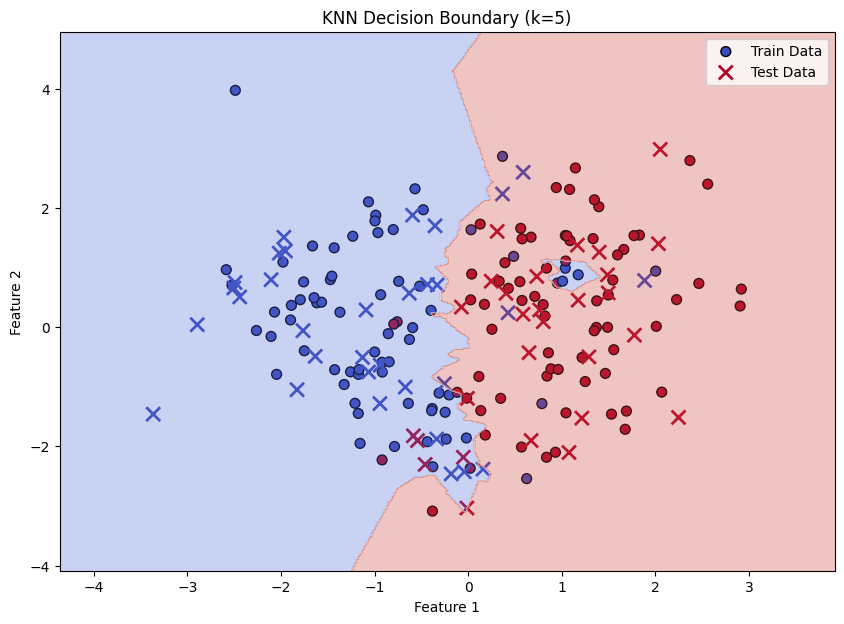

In [42]:
# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_knn)

# Evaluate the model
accuracy_knn = accuracy_score(y_test_knn, y_pred_knn)
print(f"KNN Model Evaluation:\nAccuracy: {accuracy_knn:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_knn, y_pred_knn))

# Visualize the decision boundary
plt.figure(figsize=(10, 7))

# Plot the training points
plt.scatter(X_train_knn[:, 0], X_train_knn[:, 1], c=y_train_knn, cmap=plt.cm.coolwarm, edgecolors='k', marker='o', s=50, label='Train Data')
# Plot the test points
plt.scatter(X_test_knn[:, 0], X_test_knn[:, 1], c=y_test_knn, cmap=plt.cm.coolwarm, edgecolors='k', marker='x', s=100, linewidths=2, label='Test Data')

# Create a mesh to plot the decision boundary
x_min, x_max = X_knn[:, 0].min() - 1, X_knn[:, 0].max() + 1
y_min, y_max = X_knn[:, 1].min() - 1, X_knn[:, 1].max() + 1
h = .02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = knn_model.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KNN Decision Boundary (k=5)')
plt.legend()
plt.show()

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

print("Libraries imported successfully for Decision Tree.")

Libraries imported successfully for Decision Tree.


In [44]:
# Generate a synthetic dataset for binary classification
X_dt, y_dt = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, random_state=42)

# Split data into training and testing sets
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_dt, y_dt, test_size=0.3, random_state=42)

print("Synthetic dataset generated and split for Decision Tree.")

Synthetic dataset generated and split for Decision Tree.


In [45]:
# Initialize and train the Decision Tree model
# We can control complexity with parameters like max_depth, min_samples_leaf, etc.
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_dt, y_train_dt)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


Decision Tree Model Evaluation:
Accuracy: 0.8000

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.88      0.82        32
           1       0.83      0.71      0.77        28

    accuracy                           0.80        60
   macro avg       0.81      0.79      0.80        60
weighted avg       0.80      0.80      0.80        60



/tmp/ipykernel_614/1385428639.py:16: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_dt[:, 0], X_test_dt[:, 1], c=y_test_dt, cmap=plt.cm.coolwarm, edgecolors='k', marker='x', s=100, linewidths=2, label='Test Data')


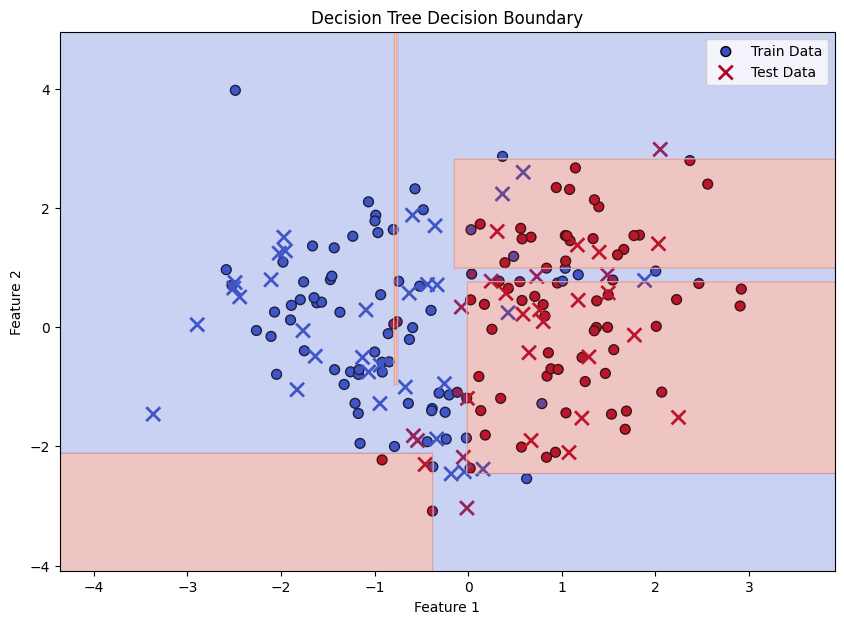

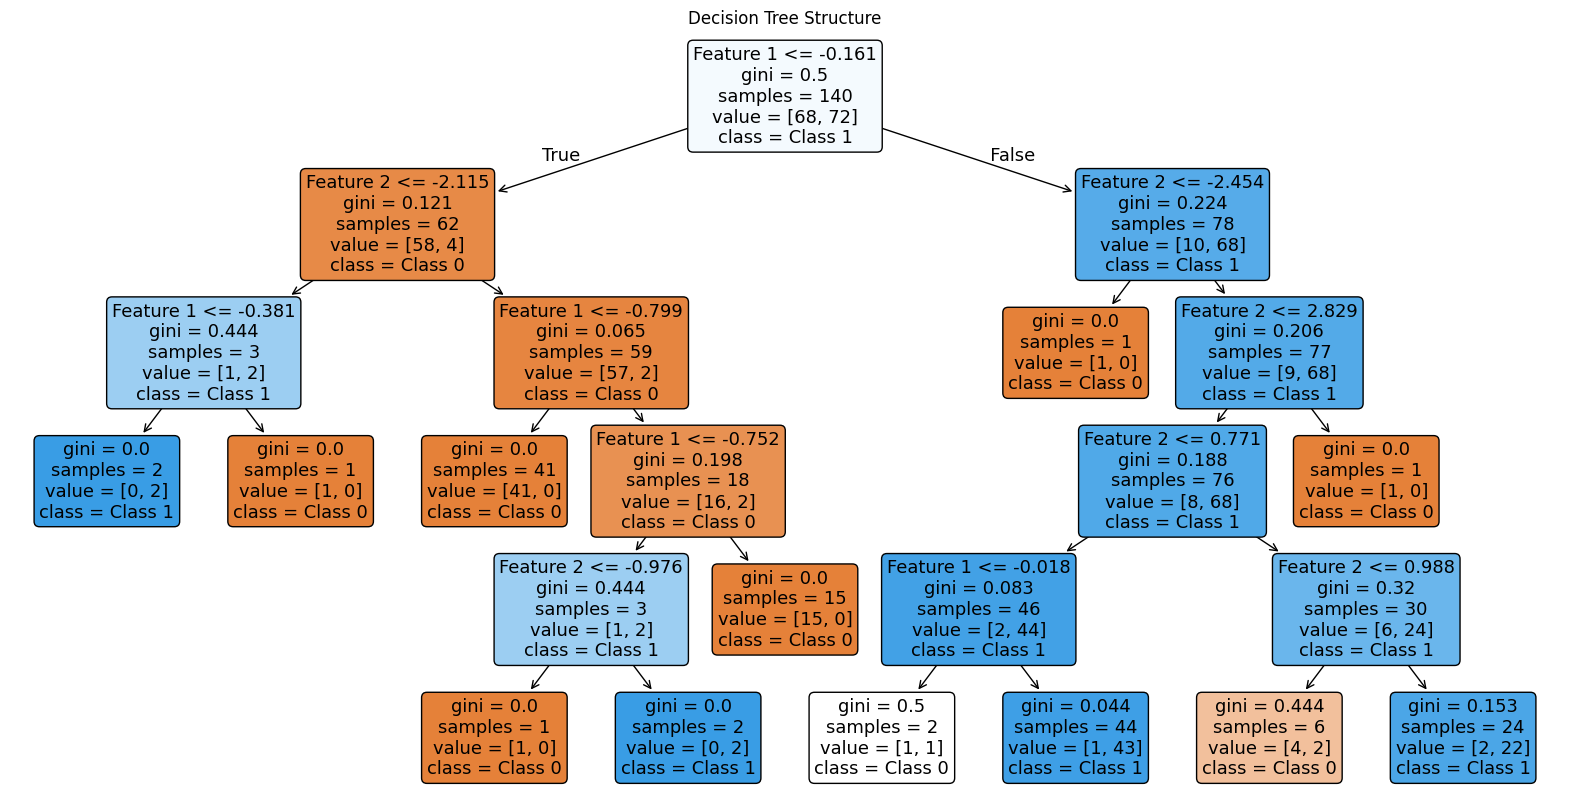

In [46]:
# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test_dt)

# Evaluate the model
accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
print(f"Decision Tree Model Evaluation:\nAccuracy: {accuracy_dt:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_dt, y_pred_dt))

# Visualize the decision boundary
plt.figure(figsize=(10, 7))

# Plot the training points
plt.scatter(X_train_dt[:, 0], X_train_dt[:, 1], c=y_train_dt, cmap=plt.cm.coolwarm, edgecolors='k', marker='o', s=50, label='Train Data')
# Plot the test points
plt.scatter(X_test_dt[:, 0], X_test_dt[:, 1], c=y_test_dt, cmap=plt.cm.coolwarm, edgecolors='k', marker='x', s=100, linewidths=2, label='Test Data')

# Create a mesh to plot the decision boundary
x_min, x_max = X_dt[:, 0].min() - 1, X_dt[:, 0].max() + 1
y_min, y_max = X_dt[:, 1].min() - 1, X_dt[:, 1].max() + 1
h = .02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = dt_model.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Tree Decision Boundary')
plt.legend()
plt.show()

# Optional: Visualize the Decision Tree itself
plt.figure(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=['Feature 1', 'Feature 2'], class_names=['Class 0', 'Class 1'], rounded=True)
plt.title('Decision Tree Structure')
plt.show()

In [47]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully for K-Means clustering.")

Libraries imported successfully for K-Means clustering.


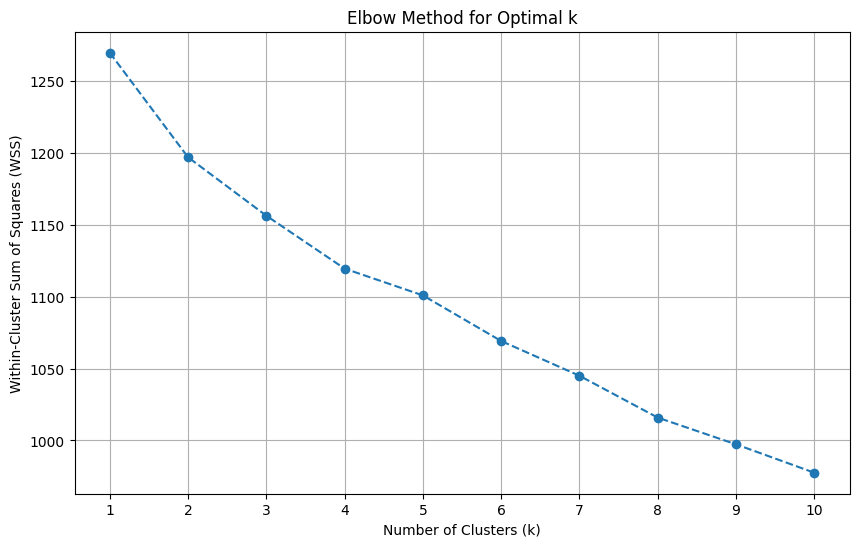

Elbow method plot generated. Look for the 'elbow' point to determine optimal k.


In [48]:
# Determine the optimal number of clusters (k) using the Elbow Method
wss = []  # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_vectorized)
    wss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print("Elbow method plot generated. Look for the 'elbow' point to determine optimal k.")

In [49]:
# Based on the elbow method, let's assume an optimal k (e.g., 2 or 3 for demonstration)
# For this example, let's choose k=2, assuming we might expect two groups (e.g., 'select' and 'reject' type characteristics).
optimal_k = 2 # You can change this based on the elbow plot

kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans_model.fit(X_vectorized)

# Get cluster labels for each resume
cluster_labels = kmeans_model.labels_

print(f"K-Means clustering with k={optimal_k} completed.")
print("Cluster distribution:")
import pandas as pd
print(pd.Series(cluster_labels).value_counts())


K-Means clustering with k=2 completed.
Cluster distribution:
1    1011
0     395
Name: count, dtype: int64


In [50]:
# Evaluate the clustering performance
inertia = kmeans_model.inertia_
silhouette_avg = silhouette_score(X_vectorized, cluster_labels)

print(f"Inertia: {inertia:.2f}")
print(f"Silhouette Score: {silhouette_avg:.4f}")

# Add cluster labels to the original DataFrame for further analysis
df['Cluster'] = cluster_labels

print("Cluster labels added to DataFrame. You can now analyze clusters.")

Inertia: 1197.01
Silhouette Score: 0.0468
Cluster labels added to DataFrame. You can now analyze clusters.


In [51]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

print("Libraries imported successfully for Random Forest.")

Libraries imported successfully for Random Forest.


In [52]:
# We'll use the already vectorized X_vectorized and the target variable y
# Split the data into training and testing sets
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

print("Data split into training and testing sets for Random Forest.")
print(f"X_train_rf shape: {X_train_rf.shape}")
print(f"X_test_rf shape: {X_test_rf.shape}")

Data split into training and testing sets for Random Forest.
X_train_rf shape: (1124, 7125)
X_test_rf shape: (282, 7125)


In [53]:
# Initialize and train the Random Forest model
# You can adjust parameters like n_estimators (number of trees) or max_depth
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_rf, y_train_rf)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [54]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_rf)

# Evaluate the model
accuracy_rf = accuracy_score(y_test_rf, y_pred_rf)
print(f"Random Forest Model Evaluation:\nAccuracy: {accuracy_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_rf, y_pred_rf))

Random Forest Model Evaluation:
Accuracy: 0.5000

Classification Report:
              precision    recall  f1-score   support

      reject       0.52      0.57      0.54       146
      select       0.48      0.43      0.45       136

    accuracy                           0.50       282
   macro avg       0.50      0.50      0.50       282
weighted avg       0.50      0.50      0.50       282



In [55]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Ensemble libraries imported successfully.")

Ensemble libraries imported successfully.


In [56]:
# Initialize the base models with the same parameters as before
# It's good practice to re-initialize for clarity in ensemble building
log_clf = LogisticRegression(random_state=42, max_iter=1000)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Create a VotingClassifier
# 'soft' voting uses predicted probabilities (if available) and averages them
# 'hard' voting uses predicted class labels and a majority vote
voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rf_clf)],
    voting='soft', # Use 'soft' for probability-based voting, 'hard' for majority vote
    weights=[0.5, 0.5] # Assign equal weights to each model
)

print("Base models and Voting Classifier initialized.")

Base models and Voting Classifier initialized.


In [57]:
# Train the Voting Classifier
voting_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_ensemble = voting_clf.predict(X_test)

# Evaluate the ensemble model
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
print(f"\nEnsemble Model Evaluation (Voting Classifier - soft voting):\nAccuracy: {accuracy_ensemble:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble))


Ensemble Model Evaluation (Voting Classifier - soft voting):
Accuracy: 0.5284

Classification Report:
              precision    recall  f1-score   support

      reject       0.54      0.65      0.59       146
      select       0.51      0.40      0.45       136

    accuracy                           0.53       282
   macro avg       0.53      0.52      0.52       282
weighted avg       0.53      0.53      0.52       282

